### 定义拟合目标函数

In [147]:
import numpy as np
import matplotlib.pyplot as plt

def target_function(x):
    """目标函数：带噪声的正弦函数"""
    return np.sin(x) + 0.1 * np.random.normal(loc=0, scale=1, size=x.shape)

# 



### 采样建立训练集和测试集

In [148]:
# 生成数据
def generate_data(n_samples=1000):
    x_train = np.linspace(-5, 5, n_samples).reshape(-1, 1)
    y_train = target_function(x_train)
    x_test = np.linspace(-5, 5, n_samples).reshape(-1, 1)
    y_test = target_function(x_test)
    return (x_train, y_train), (x_test, y_test)



### 手写各种功能函数

In [149]:
import numpy as np

# 实现矩阵乘法的正向计算和反向梯度求解
class Matmul:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x, W):
        h = np.matmul(x, W)
        self.mem={'x': x, 'W':W}
        return h
    
    def backward(self, grad_y):
        x = self.mem['x']
        W = self.mem['W']

        # 计算 grad_x：grad_x = grad_y @ W^T
        grad_x = np.matmul(grad_y, W.T)
        
        # 计算 grad_W：grad_W = x^T @ grad_y
        grad_W = np.matmul(x.T, grad_y)
        
        return grad_x, grad_W

# 实现Relu函数的正向计算和反向梯度求解
class Relu:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x):
        self.mem['x']=x
        return np.where(x > 0, x, np.zeros_like(x))
    
    def backward(self, grad_y):
        x = self.mem['x']
        grad_x = np.where(x>0, grad_y, np.zeros_like(grad_y))
        
        return grad_x

### 建立模型

In [150]:
class myModel:
    def __init__(self, input_dim=1, hidden_dim=500, output_dim=1):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.W1 = np.random.normal(scale=0.01, size=[input_dim+1, hidden_dim])
        self.W2 = np.random.normal(scale=0.01, size=[hidden_dim, output_dim])
        
        self.mul_h1 = Matmul()
        self.mul_h2 = Matmul()
        self.relu = Relu()
        
    def forward(self, x):
        x = x.reshape(-1, self.input_dim)
        bias = np.ones(shape=[x.shape[0], 1])
        x = np.concatenate([x, bias], axis=1) # 加入偏置项
        self.h1 = self.mul_h1.forward(x, self.W1)
        self.h1_relu = self.relu.forward(self.h1)
        self.h2 = self.mul_h2.forward(self.h1_relu, self.W2)

    def backward(self, label):
        self.out_grad = 2* (self.h2 - label)
        self.h1_relu_grad, self.W2_grad = self.mul_h2.backward(self.out_grad)
        self.h1_grad = self.relu.backward(self.h1_relu_grad)
        self.x_grad, self.W1_grad = self.mul_h1.backward(self.h1_grad)
        
model = myModel()



### 计算loss

In [151]:
def compute_loss(log_prob, labels):
     return np.mean(np.square(log_prob-labels))
    

def train_one_step(model, x, y):
    model.forward(x)
    model.backward(y)
    model.W1 -= 1e-4* model.W1_grad
    model.W2 -= 1e-4* model.W2_grad
    loss = compute_loss(model.h2, y)
    # accuracy = compute_accuracy(model.h2, y)
    return loss

def test(model, x, y):
    model.forward(x)
    loss = compute_loss(model.h2, y)
    # accuracy = compute_accuracy(model.h2, y)
    return loss

### 实际训练

In [152]:
(x_train, y_train), (x_test, y_test) = generate_data(n_samples=1000)

# x_train=x_train.reshape(-1,1)
# y_train=y_train.reshape(-1,1)
# x_test=x_test.reshape(-1,1)
# y_test=y_test.reshape(-1,1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

# loss, accuracy = train_one_step(model, x_train, y_train)
train_losses = []
# test_losses = []

for epoch in range(2000):
    loss = train_one_step(model, x_train, y_train)
    train_losses.append(loss)
    print('epoch', epoch, ': loss', loss)
    


test_loss = test(model, x_test, y_test)
# test_losses.append(test_loss)
print('test loss', test_loss )

(1000, 1)
(1000, 1)
(1000, 1)
(1000, 1)
epoch 0 : loss 0.5328410971431449
epoch 1 : loss 0.5303239681110012
epoch 2 : loss 0.5281081151843251
epoch 3 : loss 0.5261102007388214
epoch 4 : loss 0.524273098576316
epoch 5 : loss 0.5225553892201984
epoch 6 : loss 0.5208904724078198
epoch 7 : loss 0.5192971463645496
epoch 8 : loss 0.5177360877390591
epoch 9 : loss 0.5161948417622659
epoch 10 : loss 0.514698221997367
epoch 11 : loss 0.513227553294121
epoch 12 : loss 0.5117898630604278
epoch 13 : loss 0.5103765928349167
epoch 14 : loss 0.5089817601426149
epoch 15 : loss 0.5076039372349813
epoch 16 : loss 0.5062560947786218
epoch 17 : loss 0.5049135656848416
epoch 18 : loss 0.5036049682399922
epoch 19 : loss 0.5023001423122601
epoch 20 : loss 0.5010209139599707
epoch 21 : loss 0.49975434074173297
epoch 22 : loss 0.49849518966065626
epoch 23 : loss 0.49725314600648873
epoch 24 : loss 0.49601553598803383
epoch 25 : loss 0.4947926272331599
epoch 26 : loss 0.4935698782177858
epoch 27 : loss 0.492353

### 可视化

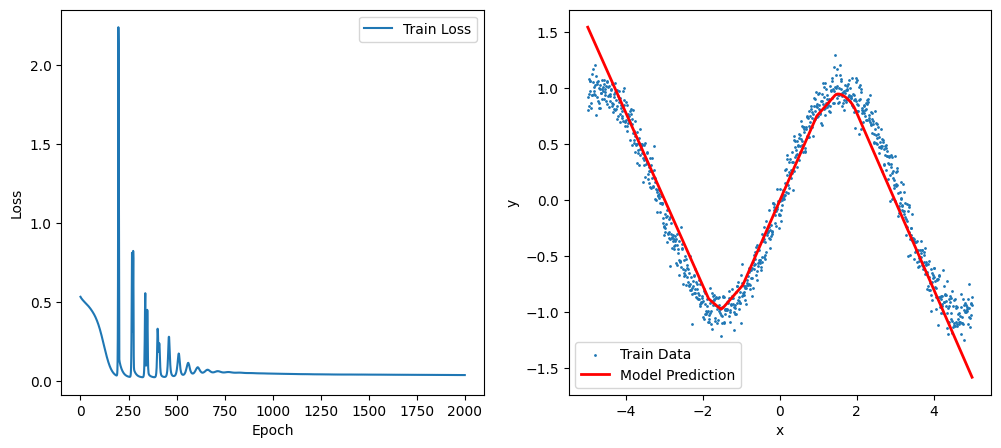

In [153]:
# 绘制损失曲线
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
# plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 绘制拟合结果
plt.subplot(1, 2, 2)
x_plot = np.linspace(-5, 5, 1000).reshape(-1,1)
model.forward(x_plot)
y_pred = model.h2
plt.scatter(x_train, y_train, s=1, label='Train Data')
plt.plot(x_plot, y_pred, 'r-', lw=2, label='Model Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.show()